## <span style="color:blue"> Lezione 6 </span>



In [74]:

import matplotlib.pyplot as plt
import numpy as np



### <span style="color:DodgerBlue"> Esercizio 6.1  </span>



L'hamiltoniana del modello di Ising unidimensionale è data dalla seguente espressione (in unità di misura tali che $\mu_B=1$ e $k_B=1$ e assunte condizioni periodiche al contorno $s_{N+1}=s_1$):$$ H = 
-J\sum_{i=1}^{N_s} s_i s_{i+1}
-\frac{h}{2}\sum_{i=1}^{N_s} (s_i + s_{i+1}) $$
 
La funzione di partizione è data da $$ Z=\sum_{\{ s_i \}} \exp \left( -\beta H\right) $$ , con $\beta=1/T$, ed è calcolabile esattamente. Di conseguenza, anche le seguenti quantità hanno una forma chiusa: energia interna per particella ($U(N,T,h)/N$), capacità termica ($C(N,T,h)$), suscettibilità ($\chi(N,T,h)$) e magnetizzazione ($M(N,T,h)$). Quest'ultima risulta nulla se $h=0$. 


L'implementazione in codice delle formule delle quantità sopra nominate è riportata nella cella sottostante. I parametri sono stati fissati a $J=1$ (sistema ferromagnetico), $N_s=50$ spin. 


In [75]:
J = 1.0 #termine pairing
Ns = 50 #numero spin

#Energia totale(h=0)

def te(T):
        th = np.tanh(J/T)
        thN= th**Ns
        ch = 1/th
        return -J*( th + ch*thN )/( 1 + thN )

#Calore specifico (h=0)
def heat(T):
        th = np.tanh(J/T)
        thN= th**Ns
        ch = 1/th
        beta=1/T
        return ((beta*J)**2)*(((1+thN+(Ns-1)*(th**2)+(Ns-1)*(ch**2)*thN)/(1+thN))-Ns*((th+ch*thN)/(1+thN))**2)


#Magnetizzazione

def M(T): 
        h=0.02 #external field
        b = 1/T

        l1 = np.exp(b*J)*np.cosh(b*h)+np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        l2 = np.exp(b*J)*np.cosh(b*h)-np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))
        Z = l1**Ns + l2**Ns
        M = (np.exp(b*J)*np.sinh(b*h)*((l1**(Ns-1))*(1+np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J))) 
                + (l2**(Ns-1))*(1-np.exp(b*J)*np.cosh(b*h)/np.sqrt(np.exp(2*b*J)*np.cosh(b*h)*np.cosh(b*h)-2*np.sinh(2*b*J)))))/(Z)
        return M
#Suscettibilità (h=0)

def X(T):
        beta=1/T
        th = np.tanh(J/T)
        thN= th**Ns
        return beta*np.exp(2*beta*J)*(1-thN)/(1+thN)

Oltre che tramite le rispettive formule chiuse, le quantità sopra elencate possono essere calcolate nella seguente maniera:

1. $U(N,T,h) = \langle H \rangle_{h=0}$
2. $C(N,T,h) = k_B \beta^2 (\langle H^2 \rangle_{h=0}-\langle H \rangle_{h}^2)$ 
3. $M(N,T,h)= \langle \sum_{i=1,N_s}s_i \rangle_{h}$
4. $\chi(N,T,h) = \beta \left( \langle (\sum_{i=1,N_s}s_i)^2 \rangle_{h}-\langle \sum_{i=1,N_s}s_i \rangle_{h}^2\right)$

Ciò si presta ad essere eseguito con una simulazione. Con $h=0$ verranno calcolate $U(N,T,h=0)/N$, $C(N,T,h=0)$ e $\chi(N,T,h=0)$, ma non la magnetizzazione, che per $h=0$ è nulla. Quest'ultima verrà calcolata con $h=0.02$. Si nota che l'espressione per la suscettibilità si semplifica: $\chi(N,T,h) =\beta  \langle (\sum_{i=1,N_s}s_i)^2 \rangle_{h=0} $. 

Verranno effettuate simulazioni con $T$ nel range $[0.5,2.0]$ a passi di $0.1$. I punti così ottenuti verranno poi messi a confronto coi risultati teorici. Nella cella sottostante sono riportate le costruzioni degli array di temperature: T_values con passo $0.1$ contiene le temperature per cui sono state effettuate le simulazioni, mentre $T$, con passo molto più fine, serve per il plot delle funzioni teoriche.


In [76]:
T_min=0.5
T_max=2.0
delta=0.1

R=int((T_max-T_min)/delta) #numero punti per grafico simulazioni
T_values=np.linspace(T_min,T_max,R+1)
points=10000
T = np.linspace(T_min-0.1,T_max+0.1,num=points)



Il sampling della distribuzione  viene fatto con due metodi, che vengono messi a confronto: Metropolis e Gibbs. Questi due metodi necessitano di una fase di equilibrazione: per accorciare il più possibile questo periodo si parte con una configurazione di spin totalmente casuale (corrispondente a $T=\infty$) impostando la temperatura più alta ($T=2.0$). Una volta finita questa simulazione, si utilizza l'ultima configurazione di spin raggiunta come punto di partenza per la successiva ($T=1.9$) e così via, fino a raggiungere $T=0.5$. Le configurazioni di Ising sono molto correlate l'una con l'altra, per cui è necessario utilizzare data blocking con un numero di step per blocco sufficientemente grande. Si è scelto numero di blocchi $N=20$ e numero di step per blocco $M=100000$. Nota: per come è implementato il codice, uno step corrisponde a estrarre $N_S$ volte uno spin a random e applicare su di esso l'algoritmo di Metropolis o Gibbs. Per equilibrare la simulazione, il sistema è stato fatto evolvere per $R=10^6$ step (nota: è eccessivo) senza effettuare alcuna misura. 



L'algoritmo di Metropolis è già implementato, mentre l'algoritmo di Gibbs viene implementato nel modo seguente: 
1. Si sceglie randomicamente uno spin $s_k$
2. Si calcola $\Delta E= H(s_k=-1) - H(s_k=1)= 2 (h + J (s_{k+1}+s_{k-1}))$
3. Si pone $$s_k =\begin{cases}  \ 1 \quad & \text{con probabilità }  1/(1+\exp(-\beta \Delta E)) \\
                                -1 \quad & \text{con probabilità }  1/(1+\exp(\beta \Delta E)) \end{cases}$$

Nelle celle sottostanti vengono caricati i dati delle simulazioni con $h=0$ per Gibbs e Metropolis. 

In [77]:

#carica i dati della simulazione con Metropolis, h=0
metro_tot_en=np.zeros(len(T_values))
metro_tot_en_err=np.zeros(len(T_values))
metro_cv=np.zeros(len(T_values))
metro_cv_err=np.zeros(len(T_values))
metro_chi=np.zeros(len(T_values))
metro_chi_err=np.zeros(len(T_values))





parent_folder="l_06_es1/OUTPUT_METRO_h_0/"

for i,temp in enumerate(T_values): 
    folder_name=parent_folder+f"T_{temp:.1f}/"
    #carica l'energia totale
    temp_val,temp_err= np.loadtxt(folder_name+"total_energy.dat",usecols=(2,3),unpack=True)
    metro_tot_en[i]=temp_val[-1]
    metro_tot_en_err[i]=temp_err[-1]
    #carica il calore specifico
    temp_val,temp_err= np.loadtxt(folder_name+"specific_heat.dat",usecols=(2,3),unpack=True)
    metro_cv[i]=temp_val[-1]
    metro_cv_err[i]=temp_err[-1]
    #carica la suscettibilità
    temp_val,temp_err= np.loadtxt(folder_name+"susceptibility.dat",usecols=(2,3),unpack=True)
    metro_chi[i]=temp_val[-1]
    metro_chi_err[i]=temp_err[-1]






In [78]:

#carica i dati della simulazione con Gibbs, h=0
gibbs_tot_en=np.zeros(len(T_values))
gibbs_tot_en_err=np.zeros(len(T_values))
gibbs_cv=np.zeros(len(T_values))
gibbs_cv_err=np.zeros(len(T_values))
gibbs_chi=np.zeros(len(T_values))
gibbs_chi_err=np.zeros(len(T_values))



parent_folder="l_06_es1/OUTPUT_GIBBS_h_0/"

for i,temp in enumerate(T_values): 
    folder_name=parent_folder+f"T_{temp:.1f}/"
    #carica l'energia totale
    temp_val,temp_err= np.loadtxt(folder_name+"total_energy.dat",usecols=(2,3),unpack=True)
    gibbs_tot_en[i]=temp_val[-1]
    gibbs_tot_en_err[i]=temp_err[-1]
    #carica il calore specifico
    temp_val,temp_err= np.loadtxt(folder_name+"specific_heat.dat",usecols=(2,3),unpack=True)
    gibbs_cv[i]=temp_val[-1]
    gibbs_cv_err[i]=temp_err[-1]
    #carica la suscettibilità
    temp_val,temp_err= np.loadtxt(folder_name+"susceptibility.dat",usecols=(2,3),unpack=True)
    gibbs_chi[i]=temp_val[-1]
    gibbs_chi_err[i]=temp_err[-1]

 


Di seguito, vengono riportati i grafici delle quantità indicate. Siccome le barre di errore sono troppo piccole per essere visualizzate, i grafici vengono affiancati dal plot dei residui:
$f_{\mathrm{data}}(T) - f_{\mathrm{teo}}(T)$, in cui le barre di errore risultano apprezzabili. 

### Energia totale per particella

Text(0.5, 1.0, 'Residui ')

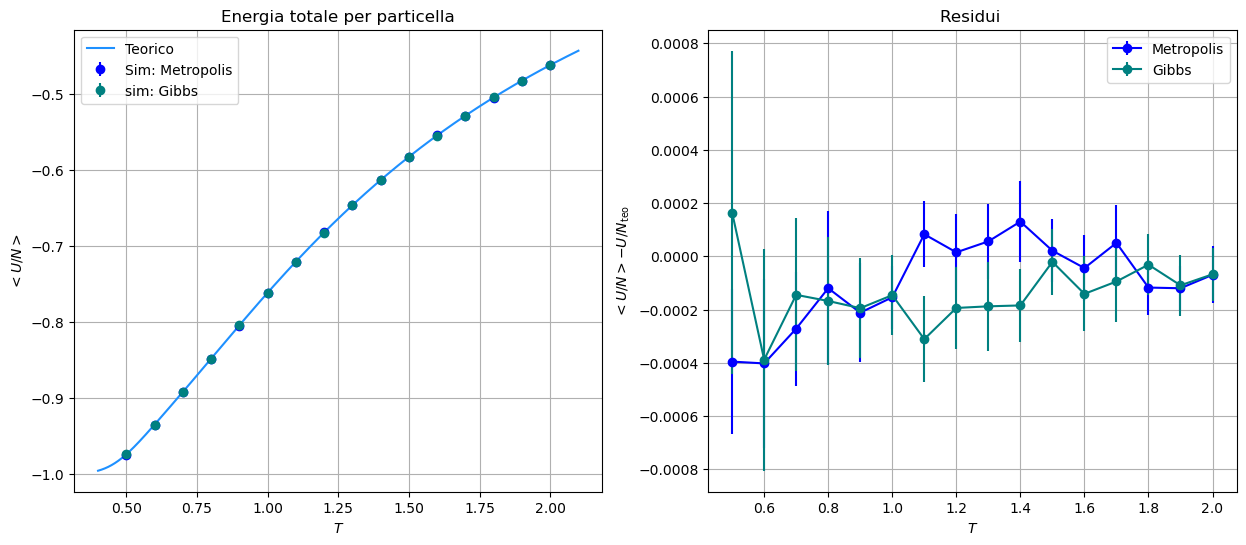

In [79]:
fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].errorbar(T_values,metro_tot_en,yerr=metro_tot_en_err,label="Sim: Metropolis",fmt="o",color="blue")
axs[0].errorbar(T_values,gibbs_tot_en,yerr=gibbs_tot_en_err,label="sim: Gibbs",fmt="o",color="teal")
axs[0].plot(T,te(T),label="Teorico",color="dodgerblue")
axs[0].grid(True)
axs[0].legend()
axs[0].set_xlabel(r"$T$")
axs[0].set_ylabel(r"$<U/N>$")
axs[0].set_title("Energia totale per particella")


metro_r=(metro_tot_en-te(T_values)) #residuo
gibbs_r=(gibbs_tot_en-te(T_values)) #residuo

axs[1].errorbar(T_values,metro_r,metro_tot_en_err,fmt="-o",label="Metropolis",color="blue")
axs[1].errorbar(T_values,gibbs_r,gibbs_tot_en_err,fmt="-o",label="Gibbs",color="teal")
axs[1].grid(True)
axs[1].legend()
axs[1].set_xlabel(r"$T$")
axs[1].set_ylabel(r"$<U/N>-U/N_{\mathrm{teo}}$")
axs[1].set_title("Residui ")




### Capacità termica

Text(0.5, 1.0, 'Residui ')

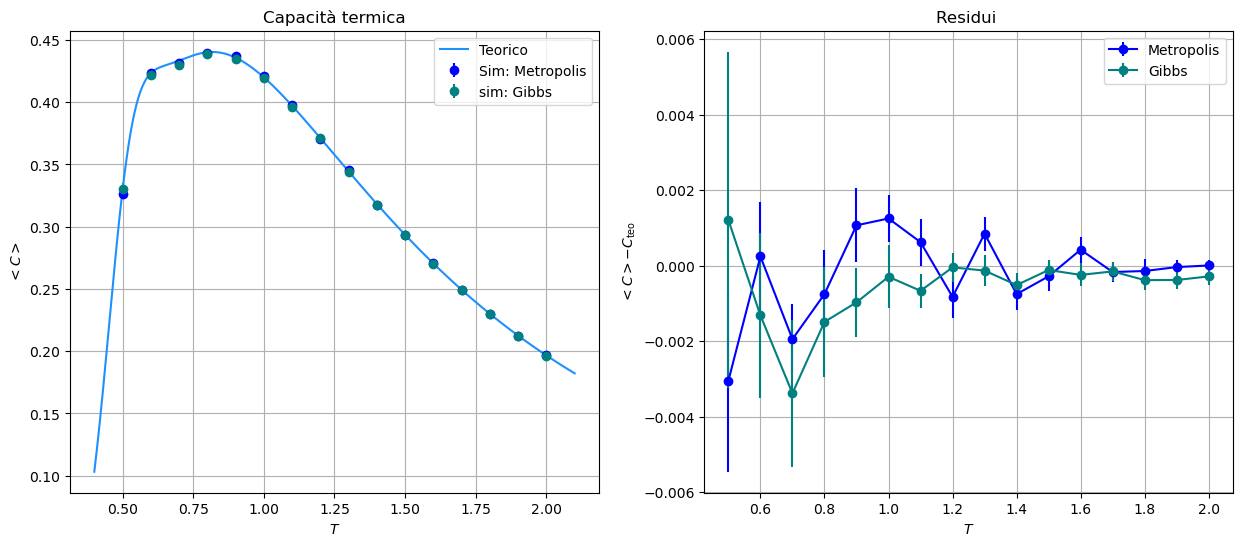

In [87]:
fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].errorbar(T_values,metro_cv,yerr=metro_cv_err,label="Sim: Metropolis",fmt="o",color="blue")
axs[0].errorbar(T_values,gibbs_cv,yerr=gibbs_cv_err,label="sim: Gibbs",fmt="o",color="teal")
axs[0].plot(T,heat(T),label="Teorico",color="dodgerblue")
axs[0].grid(True)
axs[0].legend()
axs[0].set_xlabel(r"$T$")
axs[0].set_ylabel(r"$<C>$")
axs[0].set_title("Capacità termica")



metro_r=(metro_cv-heat(T_values))#residuo
gibbs_r=(gibbs_cv-heat(T_values)) #residuo



axs[1].errorbar(T_values,metro_r,metro_cv_err,label="Metropolis",fmt="-o",color="blue")
axs[1].errorbar(T_values,gibbs_r,gibbs_cv_err,label="Gibbs",fmt="-o",color="teal")
axs[1].grid(True)
axs[1].legend()
axs[1].set_xlabel(r"$T$")
axs[1].set_ylabel(r"$<C>-C_{\mathrm{teo}}$")
axs[1].set_title("Residui ")





### Suscettibilità

Text(0.5, 1.0, 'Residui ')

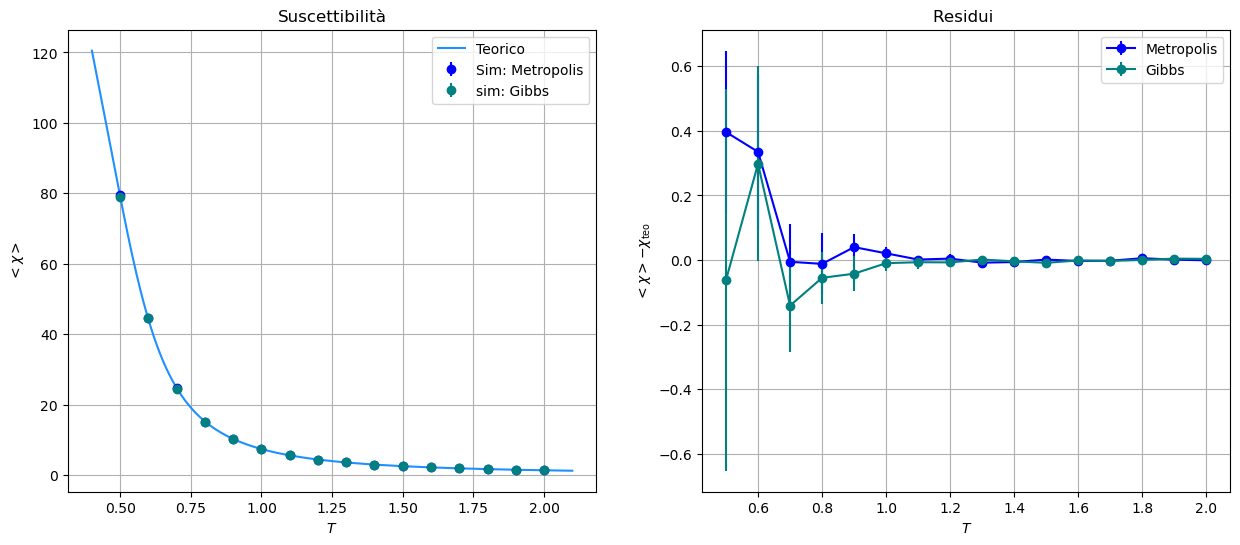

In [81]:
fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].errorbar(T_values,metro_chi,yerr=metro_chi_err,label="Sim: Metropolis",fmt="o",color="blue")
axs[0].errorbar(T_values,gibbs_chi,yerr=gibbs_chi_err,label="sim: Gibbs",fmt="o",color="teal")
axs[0].plot(T,X(T),label="Teorico",color="dodgerblue")
axs[0].grid(True)
axs[0].legend()
axs[0].set_xlabel(r"$T$")
axs[0].set_ylabel(r"$<\chi>$")
axs[0].set_title("Suscettibilità")

metro_r=(metro_chi-X(T_values)) #residuo
gibbs_r=(gibbs_chi-X(T_values)) #residuo

axs[1].errorbar(T_values,metro_r,metro_chi_err,label="Metropolis",color="blue",fmt="-o")
axs[1].errorbar(T_values,gibbs_r,gibbs_chi_err,label="Gibbs",color="teal",fmt="-o")
axs[1].grid(True)
axs[1].legend()
axs[1].set_xlabel(r"$T$")
axs[1].set_ylabel(r"$<\chi>-\chi_{\mathrm{teo}}$")
axs[1].set_title("Residui ")





Di seguito si trova invece il codice che carica i dati di $M(N,T,h=0.02)$ per Gibbs e Metropolis.

In [82]:

#carica i dati delle simulazione con h=0.02
metro_magn=np.zeros(len(T_values))
metro_magn_err=np.zeros(len(T_values))
gibbs_magn=np.zeros(len(T_values))
gibbs_magn_err=np.zeros(len(T_values))

metro_parent_folder="l_06_es1/OUTPUT_METRO_h_0.02/"
gibbs_parent_folder="l_06_es1/OUTPUT_GIBBS_h_0.02/"


for i,temp in enumerate(T_values): 
    #carica la magnetizzazione (metropolis)
    folder_name=metro_parent_folder+f"T_{temp:.1f}/"
    temp_val,temp_err= np.loadtxt(folder_name+"magnetization.dat",usecols=(2,3),unpack=True)
    metro_magn[i]=temp_val[-1]
    metro_magn_err[i]=temp_err[-1]

    #carica la magnetizzazione (gibbs)
    folder_name=gibbs_parent_folder+f"T_{temp:.1f}/"
    temp_val,temp_err= np.loadtxt(folder_name+"magnetization.dat",usecols=(2,3),unpack=True)
    gibbs_magn[i]=temp_val[-1]
    gibbs_magn_err[i]=temp_err[-1]



### Magnetizzazione

Text(0.5, 1.0, 'Residui ')

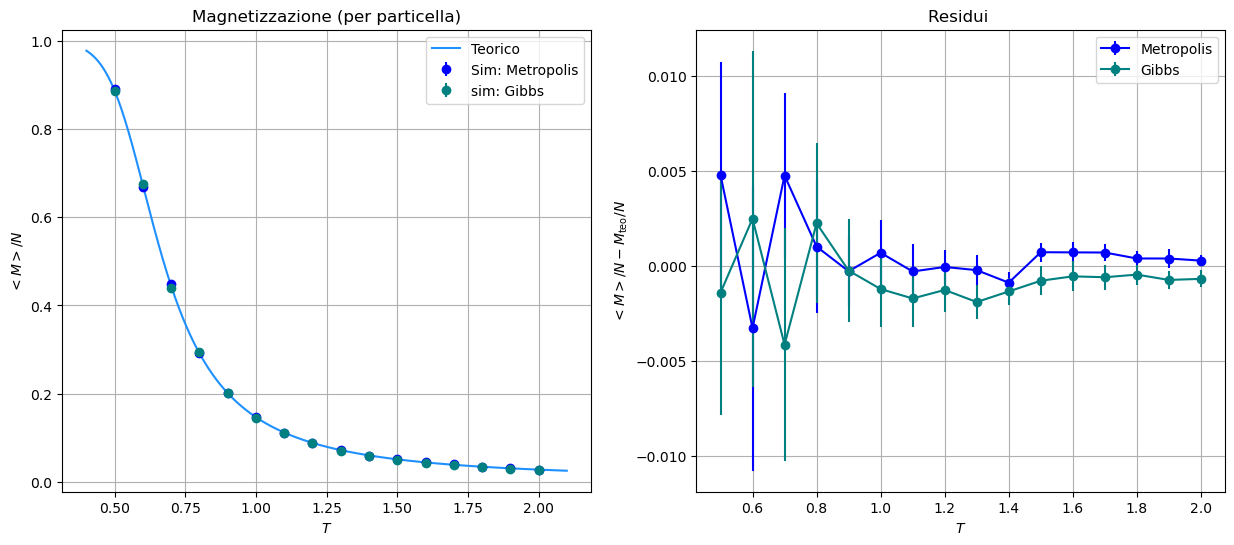

In [83]:
fig,axs=plt.subplots(1,2,figsize=[15,6])

axs[0].errorbar(T_values,metro_magn,yerr=metro_magn_err,label="Sim: Metropolis",fmt="o",color="blue")
axs[0].errorbar(T_values,gibbs_magn,yerr=gibbs_magn_err,label="sim: Gibbs",fmt="o",color="teal")
axs[0].plot(T,M(T),label="Teorico",color="dodgerblue")

axs[0].grid(True)
axs[0].legend()
axs[0].set_xlabel(r"$T$")
axs[0].set_ylabel(r"$<M>/N$")
axs[0].set_title("Magnetizzazione (per particella)")

metro_r=(metro_magn-M(T_values))#residuo
gibbs_r=(gibbs_magn-M(T_values))#residuo

axs[1].errorbar(T_values,metro_r,metro_magn_err,label="Metropolis",color="blue",fmt="-o")
axs[1].errorbar(T_values,gibbs_r,gibbs_magn_err,label="Gibbs",color="teal",fmt="-o")
axs[1].grid(True)
axs[1].legend()
axs[1].set_xlabel(r"$T$")
axs[1].set_ylabel(r"$<M>/N-M_{\mathrm{teo}}/N$")
axs[1].set_title("Residui ")


C'è un discreto accordo tra le previsioni teoriche e i dati sperimentali, che migliora all'aumentare della temperatura. 

## Controllo equilibrazione

In [84]:

NB=100000

gibbs_h0_tot_en=[]
metro_h0_tot_en=[]
gibbs_h002_tot_en=[]
metro_h002_tot_en=[]




parent_folder="l_06_es1/equilibration_100000step/OUTPUT_"



for i,temp in reversed(list(enumerate(T_values))): 
    folder_name=parent_folder+"METRO_h_0/" +f"T_{temp:.1f}/"
    metro_h0_tot_en.append(np.loadtxt(folder_name+"total_energy.dat",usecols=2))
    folder_name=parent_folder+"GIBBS_h_0/" +f"T_{temp:.1f}/"
    gibbs_h0_tot_en.append(np.loadtxt(folder_name+"total_energy.dat",usecols=2))
    folder_name=parent_folder+"METRO_h_0.02/" +f"T_{temp:.1f}/"
    metro_h002_tot_en.append(np.loadtxt(folder_name+"total_energy.dat",usecols=2))
    folder_name=parent_folder+"GIBBS_h_0.02/" +f"T_{temp:.1f}/"
    gibbs_h002_tot_en.append(np.loadtxt(folder_name+"total_energy.dat",usecols=2))
    
    

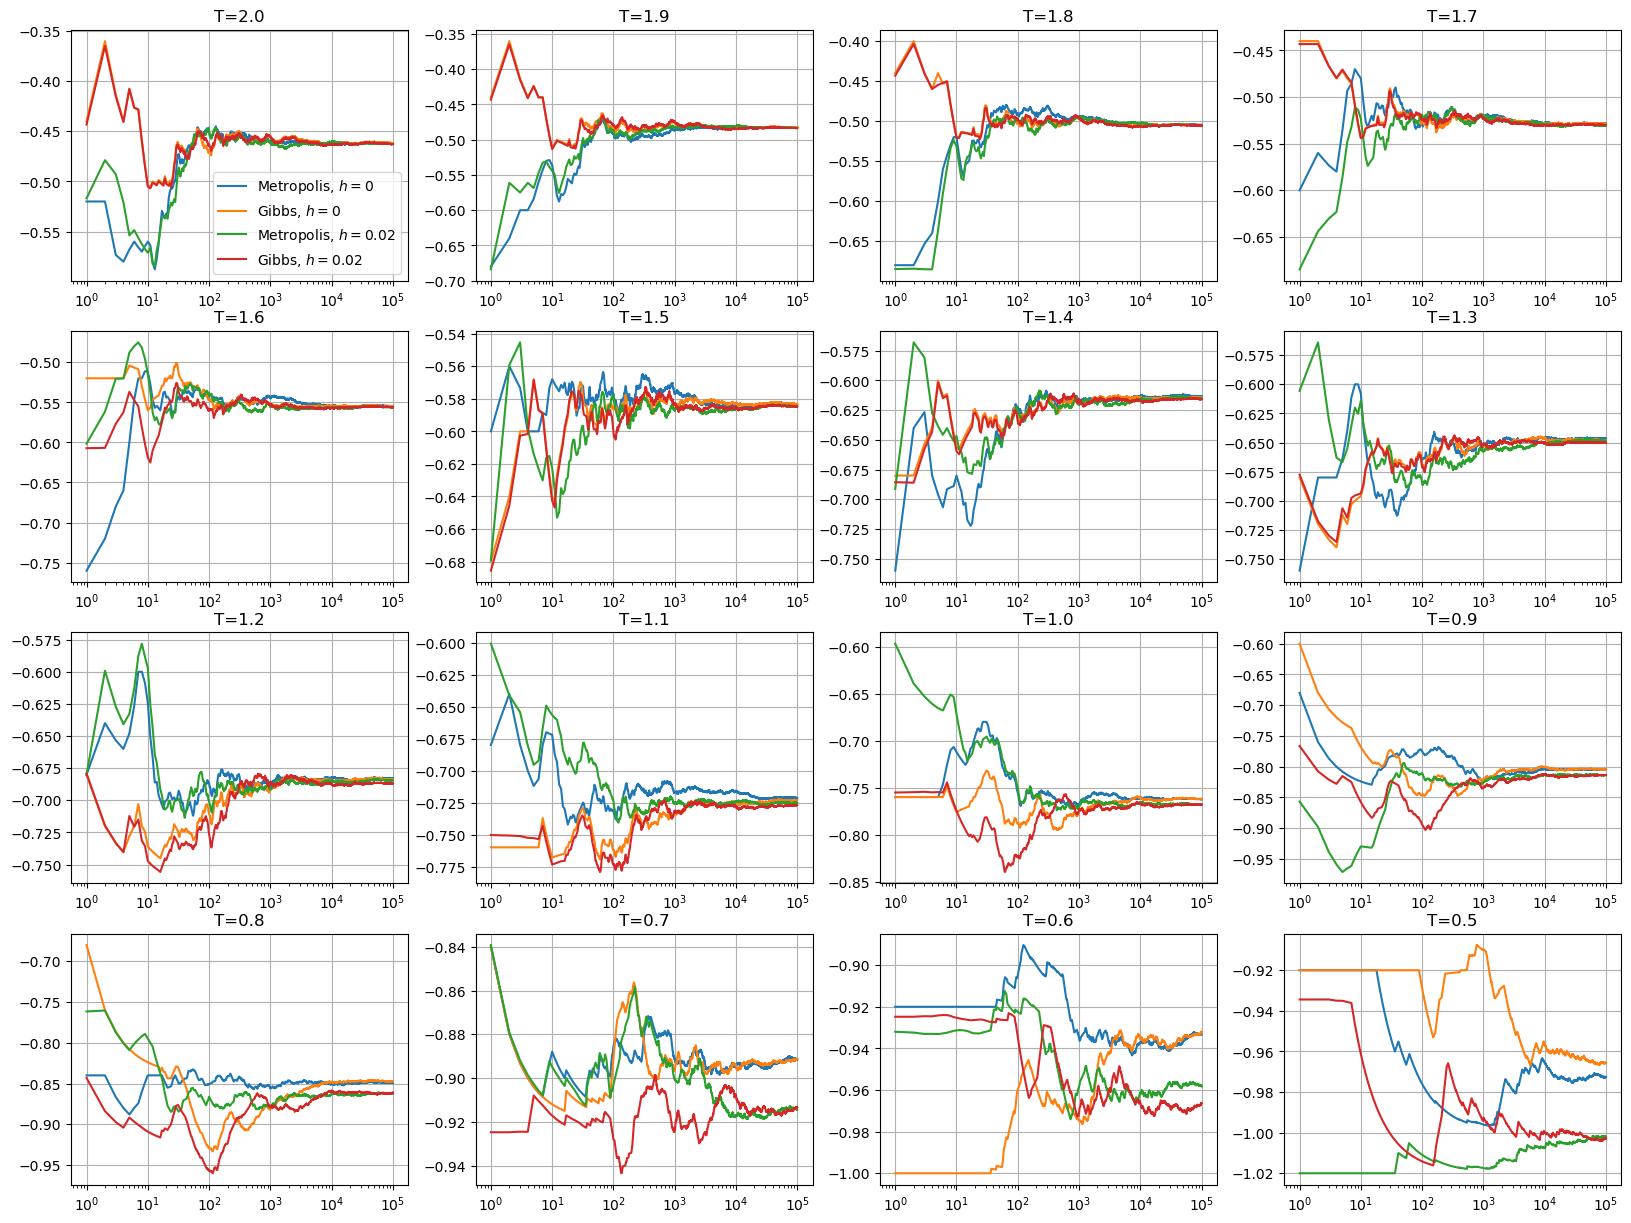

In [85]:
fig,axs=plt.subplots(4,4,figsize=[20,15])

n=np.arange(1,NB+1)#numero step

for i,ax in enumerate(axs.flatten()):
    temp=T_values[-1-i]
    ax.plot(n,metro_h0_tot_en[i],label=r"Metropolis, $h=0$")
    ax.plot(n,gibbs_h0_tot_en[i],label=r"Gibbs, $h=0$")
    ax.plot(n,metro_h002_tot_en[i],label=r"Metropolis, $h=0.02$")
    ax.plot(n,gibbs_h002_tot_en[i],label=r"Gibbs, $h=0.02$")
    ax.set_title(f"T={temp:.1f}")
    ax.grid()
    ax.semilogx()
    if i==0: 
        ax.legend()



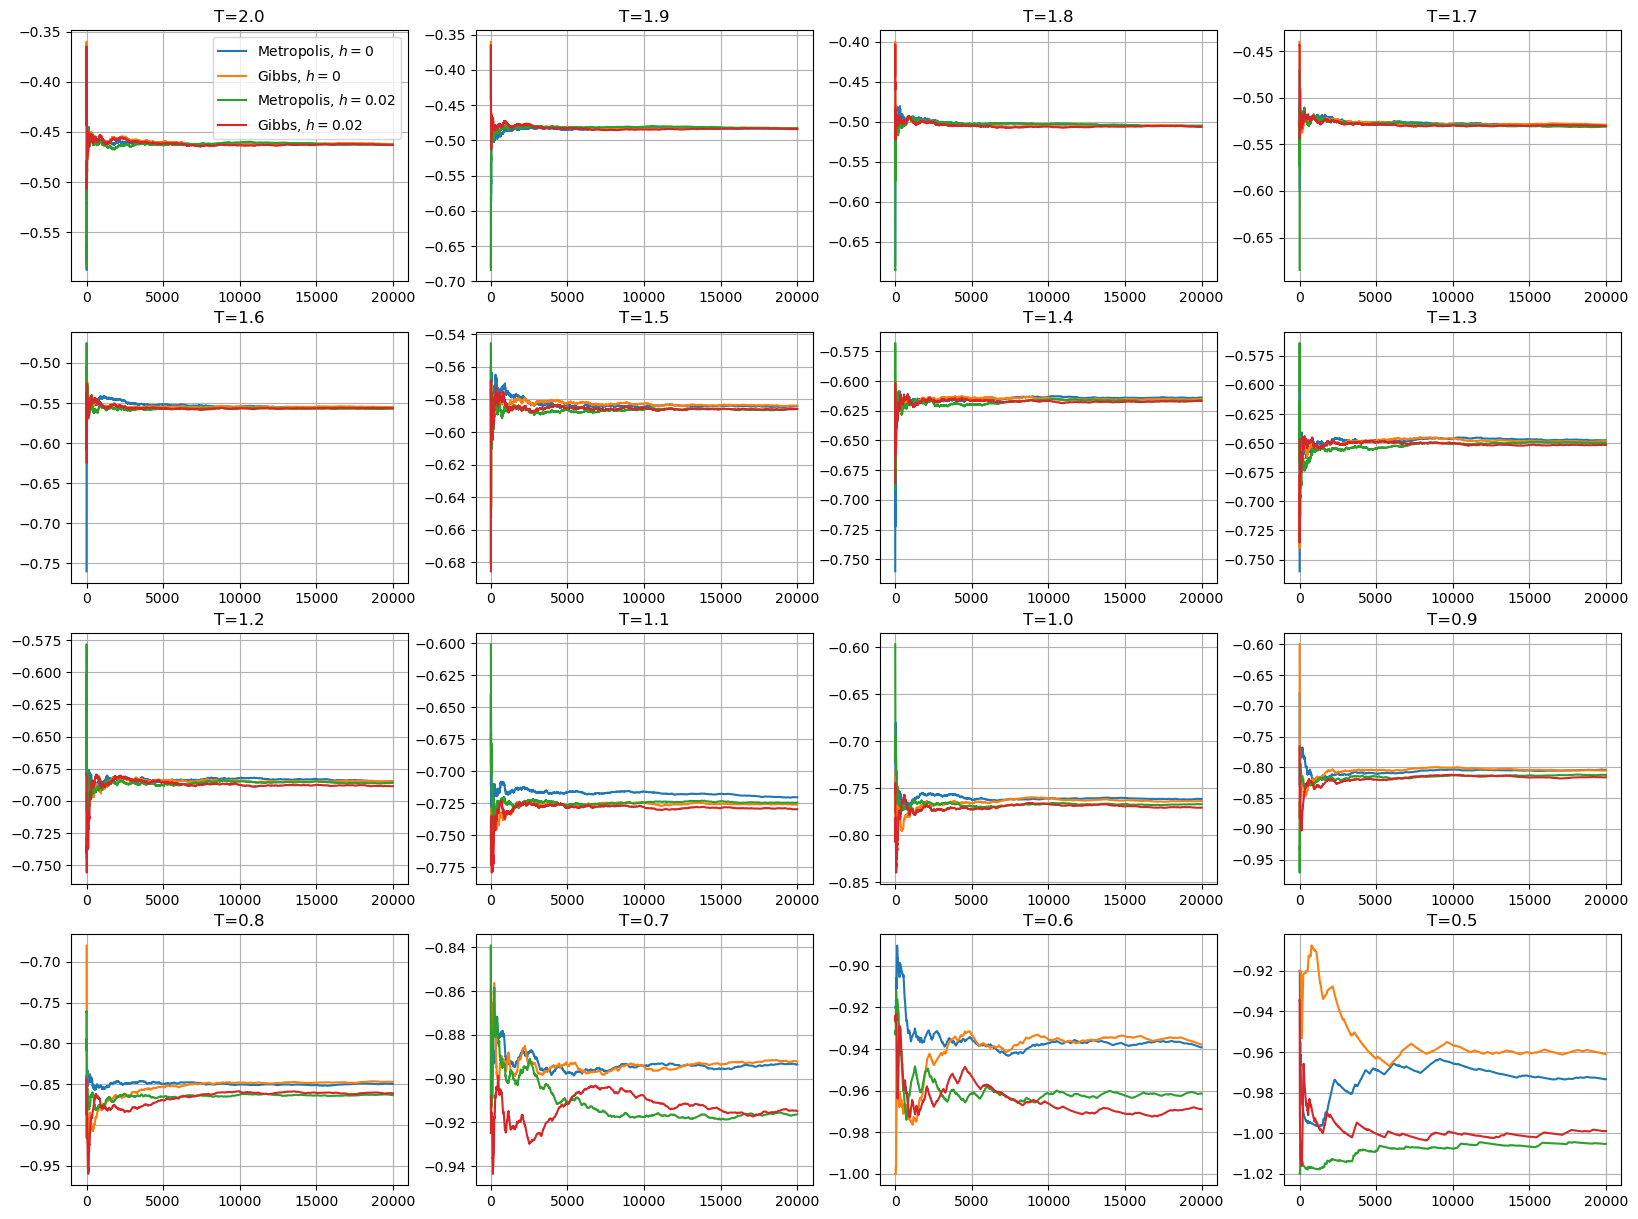

In [86]:
fig,axs=plt.subplots(4,4,figsize=[20,15])

n=np.arange(1,20001)#numero step

for i,ax in enumerate(axs.flatten()):
    temp=T_values[-1-i]
    ax.plot(n,metro_h0_tot_en[i][:20000],label=r"Metropolis, $h=0$")
    ax.plot(n,gibbs_h0_tot_en[i][:20000],label=r"Gibbs, $h=0$")
    ax.plot(n,metro_h002_tot_en[i][:20000],label=r"Metropolis, $h=0.02$")
    ax.plot(n,gibbs_h002_tot_en[i][:20000],label=r"Gibbs, $h=0.02$")
    ax.set_title(f"T={temp:.1f}")
    ax.grid()
    if i==0: 
        ax.legend()

